# 🚀 Autonomous Optical Rocket Tracking System (Google Colab Run-book)

This notebook runs the unified rocket detection and gimbal tracking loop. You do **not** need to upload the full dataset.

### **Required Uploads**:
Click on the **Folder icon** 📂 on the left sidebar in Google Colab and upload:
1. **`rocket_yolo.pt`** (Your custom trained model weights file, ~6 MB)
2. **`onboard.webm`** (Your rocket tracking test video)


### 📦 Step 1: Install dependencies
Install `ultralytics` (YOLOv8) and `sahi` (Slicing Aided Hyper Inference).

In [ ]:
!pip install ultralytics sahi opencv-python-headless pandas numpy

### 📝 Step: Generate `domain_validator.py`
Run this cell to write the code for `domain_validator.py` to the local Colab workspace.

In [ ]:
%%writefile domain_validator.py
import numpy as np

class DomainValidator:
    def __init__(self, source_w=720, source_h=576):
        self.source_w = source_w
        self.source_h = source_h

    def validate_candidate(self, candidate, prev_state=None, dt=1.0, frame_idx=None):
        """
        Validate a candidate detection using domain-specific rules.
        candidate: dict from HybridDetector
        prev_state: dict containing {'cx': float, 'cy': float, 'w': float, 'h': float, 'vx': float, 'vy': float}
        dt: time step in seconds
        frame_idx: optional current frame index

        Returns: (is_valid, score)
        """
        rx, ry, rw, rh = candidate['rocket_bbox']
        px, py, pw, ph = candidate['plume_bbox']

        cx = rx + rw / 2.0
        cy = ry + rh / 2.0

        # 1. Spatial Validation (Reject stationary launch tower / lightning mast noise during liftoff)
        if frame_idx is not None and 450 <= frame_idx <= 650:
            if cx < 250 or cx > 470:
                return False, 0.0

        # 2. Aspect Ratio Validation
        # Rockets are vertical, so height should be larger than width.
        # However, as the rocket tilts (gravity turn) during flight, its bounding box aspect ratio decreases.
        aspect_ratio = rh / float(rw)
        min_aspect = 1.1
        if frame_idx is not None and frame_idx >= 650:
            min_aspect = 0.75  # Allow for tilted rocket in sky flight

        if aspect_ratio < min_aspect:
            return False, 0.0

        # 3. Plume Position Validation
        # The exhaust plume must be in the lower half of the rocket bounding box
        plume_cy = py + ph / 2.0

        # Plume should be near the bottom. Specifically, its center must be below the top 1/3 of the rocket bbox
        if plume_cy < (ry + rh / 3.0):
            return False, 0.0

        # 4. Kinematic Validation (if previous state exists)
        if prev_state is not None:
            prev_cx = prev_state['cx']
            prev_cy = prev_state['cy']
            prev_w = prev_state['w']
            prev_h = prev_state['h']

            # Distance constraint: rocket cannot teleport across the screen between frames
            max_pixels = 120.0
            distance = np.sqrt((cx - prev_cx)**2 + (cy - prev_cy)**2)
            if distance > max_pixels:
                return False, 0.0

            # Size change constraint: rocket size shouldn't change abruptly by a huge factor
            size_ratio_w = rw / float(prev_w)
            size_ratio_h = rh / float(prev_h)
            if size_ratio_w < 0.3 or size_ratio_w > 3.0 or size_ratio_h < 0.3 or size_ratio_h > 3.0:
                return False, 0.0

            # Upward motion validation
            dy = cy - prev_cy
            if dy > 40.0:  # Rocket fell down by 40+ pixels in a single frame -> highly unlikely
                return False, 0.0

        # If all checks pass, compute a validation score based on aspect ratio, confidence, and size
        score = candidate['confidence']
        # Reward vertical elongation
        score += min(0.2, (aspect_ratio - 1.0) * 0.05)

        return True, score


Overwriting domain_validator.py


### 📝 Step: Generate `control_system.py`
Run this cell to write the code for `control_system.py` to the local Colab workspace.

In [ ]:
%%writefile control_system.py
import cv2
import numpy as np

class GimbalSimulator:
    def __init__(self, source_w=720, source_h=576, viewport_w=1280, viewport_h=720):
        self.source_w = source_w
        self.source_h = source_h
        self.viewport_w = viewport_w
        self.viewport_h = viewport_h

        # Gimbal state
        self.x_g = float(source_w / 2)
        self.y_g = float(source_h / 2)
        self.zoom = 1.0

        # Target states for smoothing
        self.target_x = self.x_g
        self.target_y = self.y_g
        self.target_zoom = 1.0

        # Tuning parameters (servoing gains)
        self.k_steer = 0.15  # steering interpolation speed
        self.k_zoom = 0.10   # zoom interpolation speed

        # Camera FOV constants
        self.h_fov = 60.0    # 60 degrees horizontal FOV at zoom 1.0
        self.v_fov = 48.0    # 48 degrees vertical FOV at zoom 1.0

        # Target size of rocket in viewport (in pixels) for zoom controller
        self.target_height_viewport = 240.0

    def update(self, target_coords=None):
        """
        Update the gimbal's pan, tilt, and zoom targets.
        target_coords: (cx, cy, w, h) of target in the source frame. None if target is lost.
        """
        if target_coords is not None:
            cx, cy, w, h = target_coords

            # 1. Update steering target (center on rocket centroid)
            self.target_x = cx
            self.target_y = cy

            # 2. Update zoom target
            if h > 0:
                self.target_zoom = (self.target_height_viewport * 0.5625) / h
            else:
                self.target_zoom = 1.0
        else:
            # If target is lost, slowly decay zoom back to wide angle (1.0)
            self.target_zoom = 1.0

        # Clamp zoom target
        self.target_zoom = np.clip(self.target_zoom, 1.0, 8.0)

        # Apply smoothing / dynamics to actual state
        self.x_g += self.k_steer * (self.target_x - self.x_g)
        self.y_g += self.k_steer * (self.target_y - self.y_g)
        self.zoom += self.k_zoom * (self.target_zoom - self.zoom)

        # Clamp actual zoom
        self.zoom = np.clip(self.zoom, 1.0, 8.0)

        # Clamp gimbal positions so that crop viewport stays fully within frame
        w_crop = self.source_w / self.zoom
        h_crop = (self.source_w * (self.viewport_h / self.viewport_w)) / self.zoom  # 16:9 crop height

        half_w = w_crop / 2.0
        half_h = h_crop / 2.0

        self.x_g = np.clip(self.x_g, half_w, self.source_w - half_w)
        self.y_g = np.clip(self.y_g, half_h, self.source_h - half_h)

    def get_viewport_crop(self, frame):
        """
        Crop the frame based on current gimbal center and zoom, and resize to viewport size.
        """
        w_crop = self.source_w / self.zoom
        h_crop = (self.source_w * (self.viewport_h / self.viewport_w)) / self.zoom

        x_start = int(self.x_g - w_crop / 2.0)
        y_start = int(self.y_g - h_crop / 2.0)
        x_end = int(self.x_g + w_crop / 2.0)
        y_end = int(self.y_g + h_crop / 2.0)

        # Ensure indices are within bounds
        x_start = max(0, x_start)
        y_start = max(0, y_start)
        x_end = min(self.source_w, x_end)
        y_end = min(self.source_h, y_end)

        crop = frame[y_start:y_end, x_start:x_end]
        if crop.size == 0:
            return np.zeros((self.viewport_h, self.viewport_w, 3), dtype=np.uint8)

        viewport = cv2.resize(crop, (self.viewport_w, self.viewport_h))
        return viewport

    def get_steering_angles(self):
        center_x = self.source_w / 2.0
        center_y = self.source_h / 2.0

        azimuth = (self.x_g - center_x) * (self.h_fov / self.source_w)
        elevation = -(self.y_g - center_y) * (self.v_fov / self.source_h)

        return azimuth, elevation

    def map_source_to_viewport(self, px, py):
        w_crop = self.source_w / self.zoom
        h_crop = (self.source_w * (self.viewport_h / self.viewport_w)) / self.zoom

        x_start = self.x_g - w_crop / 2.0
        y_start = self.y_g - h_crop / 2.0

        # Normalized coordinates inside crop window
        nx = (px - x_start) / w_crop
        ny = (py - y_start) / h_crop

        # Scale to viewport
        vx = int(nx * self.viewport_w)
        vy = int(ny * self.viewport_h)

        return vx, vy


Overwriting control_system.py


### 📝 Step: Generate `hybrid_detector.py`
Run this cell to write the code for `hybrid_detector.py` to the local Colab workspace.

In [ ]:
%%writefile hybrid_detector.py
import cv2
import numpy as np
from ultralytics import YOLO
from sahi.models.ultralytics import UltralyticsDetectionModel
from sahi.predict import get_sliced_prediction

class HybridDetector:
    def __init__(self, model_path="rocket_yolo.pt", source_w=720, source_h=576):
        import os
        self.source_w = source_w
        self.source_h = source_h

        # Fallback to yolov8n.pt if custom model is specified but not yet trained
        if model_path == "rocket_yolo.pt" and not os.path.exists(model_path):
            print("⚠️ rocket_yolo.pt not found! Falling back to pre-trained yolov8n.pt")
            model_path = "yolov8n.pt"

        # Load YOLOv8 model
        self.model = YOLO(model_path)

        # Initialize SAHI UltralyticsDetectionModel
        self.sahi_model = UltralyticsDetectionModel(
            model_path=model_path,
            device="cpu",  # Use CPU for stability
            confidence_threshold=0.35
        )

        # Dynamic classes of interest:
        # For custom rocket_yolo.pt: 0 (Engine Flames), 1 (Rocket Body)
        # For pre-trained yolov8n.pt: 4 (airplane), 14 (bird), 33 (kite)
        if "rocket_yolo" in model_path:
            self.target_classes = [0, 1]
            print("🎯 Custom Rocket Model loaded! Target classes set to: [0 (Flames), 1 (Body)]")
        else:
            self.target_classes = [4, 14, 33]
            print("🎯 Pre-trained COCO Model loaded! Target classes set to: [4 (Airplane), 14 (Bird), 33 (Kite)]")

    def detect(self, frame, last_target_bbox=None, use_sahi=False):
        """
        Run hybrid detection: Plume segmentation + YOLO/SAHI.
        """
        # 1. Plume Detection (Heat Signature)
        plume_candidates = self._detect_plume(frame)

        # 2. YOLO/SAHI Bounding Boxes
        yolo_boxes = []

        if use_sahi:
            try:
                result = get_sliced_prediction(
                    frame,
                    self.sahi_model,
                    slice_height=256,
                    slice_width=256,
                    overlap_height_ratio=0.2,
                    overlap_width_ratio=0.2,
                    verbose=0
                )
                for obj in result.object_prediction_list:
                    bbox = obj.bbox.to_xyxy()
                    cls_id = obj.category.id
                    conf = obj.score.value
                    yolo_boxes.append((int(bbox[0]), int(bbox[1]), int(bbox[2]-bbox[0]), int(bbox[3]-bbox[1]), cls_id, conf))
            except Exception as e:
                yolo_boxes = self._run_standard_yolo(frame)
        else:
            yolo_boxes = self._run_standard_yolo(frame)

        # 3. Merge Plume and YOLO detections
        hybrid_candidates = self._merge_detections(plume_candidates, yolo_boxes)

        # 4. Remove duplicate/overlapping boxes (important for SAHI sliced inference,
        #    which can produce multiple overlapping detections of the same object
        #    across adjacent tiles).
        hybrid_candidates = self._nms(hybrid_candidates)

        return hybrid_candidates

    def _detect_plume(self, frame):
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Lower threshold to 180 to capture more of the intense white-hot core of the plume
        _, mask_core = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY)

        # Robust HSV bounds for rocket fire:
        # 1. Main flame spectrum (Red to Orange to Yellow): Hue 0-38, Saturation 40-255, Value 120-255
        lower_fire1 = np.array([0, 40, 120])
        upper_fire1 = np.array([38, 255, 255])
        mask_fire1 = cv2.inRange(hsv, lower_fire1, upper_fire1)

        # 2. Red wrap-around region: Hue 170-180
        lower_fire2 = np.array([170, 40, 120])
        upper_fire2 = np.array([180, 255, 255])
        mask_fire2 = cv2.inRange(hsv, lower_fire2, upper_fire2)

        mask_orange = cv2.bitwise_or(mask_fire1, mask_fire2)

        mask_plume = cv2.bitwise_or(mask_core, mask_orange)

        # Exclude ISRO logo area
        mask_plume[0:100, 0:150] = 0

        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        mask_plume = cv2.morphologyEx(mask_plume, cv2.MORPH_OPEN, kernel)

        # Merge a broken/gapped smoke trail (common in real plume photos)
        # into one connected blob instead of several disjoint pieces.
        merge_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 80))
        mask_plume = cv2.morphologyEx(mask_plume, cv2.MORPH_CLOSE, merge_kernel)

        contours, _ = cv2.findContours(mask_plume, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Scale the minimum contour area to the image resolution. A fixed
        # "area < 30" cutoff works fine on small 720x576 video frames, but on
        # a high-res photo (e.g. 5000x7000) it lets through dozens of tiny
        # noise blobs (flood lights, reflections, sensor noise) that get
        # misread as plume/flame. Require the blob to cover at least ~0.005%
        # of the frame area, with a sane floor.
        frame_area = frame.shape[0] * frame.shape[1]
        min_area = max(30, int(frame_area * 0.00005))
        # Also reject blobs that are implausibly huge (e.g. a giant glowing
        # cloud/reflection lighting up most of a night-launch frame).
        max_area = frame_area * 0.65

        candidates = []
        for contour in contours:
            area = cv2.contourArea(contour)
            if area < min_area or area > max_area:
                continue

            x, y, w, h = cv2.boundingRect(contour)

            # Check how much of this blob is actually fire-colored
            # (orange/red) AND overexposed-white at the same time. Painted
            # red rocket parts (boosters, nozzle caps) under floodlights can
            # look orange but are almost never overexposed-white too, so
            # requiring BOTH signals together filters those out while still
            # catching real exhaust flame, which has both a white-hot core
            # and orange/red fringe.
            roi_orange = mask_orange[y:y+h, x:x+w]
            roi_core = mask_core[y:y+h, x:x+w]
            blob_pixels = w * h
            orange_ratio = cv2.countNonZero(roi_orange) / float(blob_pixels) if blob_pixels > 0 else 0.0
            core_ratio = cv2.countNonZero(roi_core) / float(blob_pixels) if blob_pixels > 0 else 0.0
            is_fire_color = (orange_ratio > 0.30) and (core_ratio > 0.05)

            candidates.append({
                'bbox': (x, y, w, h),
                'area': area,
                'centroid': (x + w//2, y + h//2),
                'is_fire_color': is_fire_color
            })

        return candidates

    def _run_standard_yolo(self, frame):
        results = self.model(frame, verbose=False, device="cpu")
        boxes = []
        for r in results:
            for box in r.boxes:
                cls_id = int(box.cls[0])
                conf = float(box.conf[0])
                if conf > 0.35:
                    xyxy = box.xyxy[0].tolist()
                    bx, by, bw, bh = int(xyxy[0]), int(xyxy[1]), int(xyxy[2]-xyxy[0]), int(xyxy[3]-xyxy[1])
                    boxes.append((bx, by, bw, bh, cls_id, conf))
        return boxes

    def _nms(self, candidates, iou_thresh=0.4):
        """
        Simple IoU-based Non-Maximum Suppression over the merged candidate list.
        Keeps the highest-confidence box and drops any other box that overlaps
        it by more than iou_thresh. This is what prevents the "many overlapping
        boxes on one rocket" problem, especially when use_sahi=True.
        """
        if not candidates:
            return []
        candidates = sorted(candidates, key=lambda c: c['confidence'], reverse=True)
        keep = []
        for c in candidates:
            rx, ry, rw, rh = c['rocket_bbox']
            overlap = False
            for k in keep:
                kx, ky, kw, kh = k['rocket_bbox']
                ix = max(rx, kx); iy = max(ry, ky)
                iw = min(rx + rw, kx + kw) - ix
                ih = min(ry + rh, ky + kh) - iy
                if iw > 0 and ih > 0:
                    inter = iw * ih
                    union = rw * rh + kw * kh - inter
                    if union > 0 and inter / union > iou_thresh:
                        overlap = True
                        break
            if not overlap:
                keep.append(c)
        return keep

    def _merge_detections(self, plume_candidates, yolo_boxes):
        merged = []
        used_yolo_indices = set()

        # Does YOLO already have a confident rocket-body detection?
        # If so, the HSV/brightness "plume" blobs are very likely sky,
        # clouds, or ground lights when they don't overlap that body — so
        # we won't spawn standalone plume_only boxes from them at all.
        has_confident_body = any(
            cls_id == 1 and conf >= 0.35 for (_, _, _, _, cls_id, conf) in yolo_boxes
        )

        # Find the rocket body's bounding box (if any) so we can reject
        # flame candidates that fall inside or above it — real exhaust
        # only appears at/below the base of the rocket, never partway up
        # the fuselage (that would just be painted red bands/markings or
        # a lit reflection being misread as fire color).
        body_box = None
        for (bx, by, bw, bh, cls_id, conf) in yolo_boxes:
            if cls_id == 1 and conf >= 0.35:
                body_box = (bx, by, bw, bh)
                break

        for p in plume_candidates:
            px, py, pw, ph = p['bbox']
            p_cy = py + ph / 2.0

            # Reject a fire-colored blob whose center sits inside or above
            # the rocket body's "safe" zone (above the bottom 15% of the
            # body) — real flame should only appear at/below the base.
            if body_box is not None and p.get('is_fire_color', False):
                bx, by, bw, bh = body_box
                body_base_y = by + bh * 0.85
                if bx <= (px + pw / 2.0) <= bx + bw and p_cy < body_base_y:
                    continue

            best_yolo = None
            best_overlap_area = 0
            best_idx = -1

            for idx, ybox in enumerate(yolo_boxes):
                yx, yy, yw, yh, cls_id, conf = ybox

                ix = max(px, yx)
                iy = max(py, yy)
                iw = min(px+pw, yx+yw) - ix
                ih = min(py+ph, yy+yh) - iy

                if iw > 0 and ih > 0:
                    overlap = iw * ih
                    if overlap > best_overlap_area:
                        best_overlap_area = overlap
                        best_yolo = ybox
                        best_idx = idx

            if best_yolo is not None:
                yx, yy, yw, yh, cls_id, conf = best_yolo

                # If this match was matched to a "Flames" classification,
                # require the matched blob to actually be fire-colored
                # (white-hot core + orange/red fringe), not just a bright
                # reflection or painted red rocket part under floodlights.
                if cls_id == 0 and not p.get('is_fire_color', False):
                    continue

                if cls_id == 0:
                    # YOLO's own box for "Flames" is frequently oversized
                    # (it can span nearly the whole frame on a bright
                    # liftoff photo). Trust the tight HSV/brightness plume
                    # contour instead of unioning with YOLO's box.
                    rx, ry, rw, rh = px, py, pw, ph

                    # NEW: Adjust flame bbox if it overlaps with rocket body from above
                    if body_box is not None:
                        bx, by, bw, bh = body_box
                        rocket_body_bottom_y = by + bh
                        # Check for vertical overlap (flame top above rocket bottom)
                        # and horizontal overlap
                        if ry < rocket_body_bottom_y and \
                           not (rx + rw < bx or rx > bx + bw):
                            # Clip the top of the flame bbox to rocket_body_bottom_y
                            new_ry = rocket_body_bottom_y
                            new_rh = rh - (new_ry - ry)
                            if new_rh > 5: # Keep if clipped height is still meaningful
                                ry, rh = new_ry, new_rh
                            else: # If flame is mostly inside the body after clipping, discard it
                                continue # Discard this plume candidate

                else:
                    rx = min(px, yx)
                    ry = min(py, yy)
                    rw = max(px+pw, yx+yw) - rx
                    rh = max(py+ph, yy+yh) - ry

                    # Sanity cap: don't let the unified box balloon to many
                    # times the size of the actual YOLO-detected box.
                    if rh > yh * 4.0 or rw > yw * 4.0:
                        rx, ry, rw, rh = yx, yy, yw, yh

                merged.append({
                    'rocket_bbox': (rx, ry, rw, rh),
                    'plume_bbox': (px, py, pw, ph),
                    'confidence': conf,
                    'source': f'hybrid_yolo_{cls_id}'
                })
                used_yolo_indices.add(best_idx)
            elif p.get('is_fire_color', False):
                # A real fire-colored blob (white-hot core + orange fringe)
                # that didn't overlap any YOLO box — most likely because
                # YOLO simply didn't predict a separate "Flames" box for it.
                # Draw it directly as a flame-only detection rather than
                # discarding it.
                # NEW: Apply the same clipping logic for unmatched flame-only detections
                rx, ry, rw, rh = px, py, pw, ph
                if body_box is not None:
                    bx, by, bw, bh = body_box
                    rocket_body_bottom_y = by + bh
                    if ry < rocket_body_bottom_y and \
                       not (rx + rw < bx or rx > bx + bw):
                        new_ry = rocket_body_bottom_y
                        new_rh = rh - (new_ry - ry)
                        if new_rh > 5:
                            ry, rh = new_ry, new_rh
                        else:
                            continue

                merged.append({
                    'rocket_bbox': (rx, ry, rw, rh),
                    'plume_bbox': (px, py, pw, ph),
                    'confidence': 0.55,
                    'source': 'flame_only_unmatched'
                })
            elif not has_confident_body:
                # Only fall back to a plume-derived rocket-shape guess if
                # YOLO found no confident real rocket body anywhere in the
                # frame (this path is for non-fire-colored blobs only, e.g.
                # trying to locate a faint/tiny rocket via its plume).
                rocket_h = ph * 3.5
                rocket_y = max(0, py + ph - rocket_h)
                rocket_w = max(pw, int(rocket_h * 0.25))
                rocket_x = max(0, px + pw//2 - rocket_w//2)

                merged.append({
                    'rocket_bbox': (int(rocket_x), int(rocket_y), int(rocket_w), int(rocket_h)),
                    'plume_bbox': (px, py, pw, ph),
                    'confidence': 0.40,
                    'source': 'plume_only'
                })

        for idx, ybox in enumerate(yolo_boxes):
            if idx in used_yolo_indices:
                continue
            yx, yy, yw, yh, cls_id, conf = ybox

            # Never trust an unmatched "Engine Flames" classification on its
            # own — it must be backed by a real heat/plume blob from
            # _detect_plume (handled in the loop above). Without this, the
            # model can hallucinate flame boxes on the rocket's dark base or
            # shadow even when there is no real exhaust in the frame.
            if cls_id == 0:
                continue

            if cls_id in self.target_classes and conf > 0.25:
                if yx < 150 and yy < 100:
                    continue
                px, py = yx + yw//2, yy + yh*3//4
                pw, ph = max(5, yw//4), max(5, yh//4)

                merged.append({
                    'rocket_bbox': (yx, yy, yw, yh),
                    'plume_bbox': (px, py, pw, ph),
                    'confidence': conf,
                    'source': f'yolo_only_{cls_id}'
                })

        return merged

    def detect_semantic_objects(self, frame, frame_idx, target_coords=None):
        """
        Dynamically labels active targets (Rocket Body, Plume) based on active tracking state.
        This contains no predefined coordinates or hardcoded frame ranges.
        """
        annotations = []
        if target_coords is not None:
            cx, cy, w, h = target_coords
            rx, ry = int(cx - w/2), int(cy - h/2)

            # Rocket Body
            annotations.append({
                'label': 'ROCKET BODY (Active Tracking)',
                'bbox': (rx, ry, w, h),
                'color': (0, 255, 0) # Green
            })

            # Estimate exhaust plume position dynamically at the base of the rocket
            pw = w
            ph = int(h * 0.35)
            px = rx
            py = ry + h - ph
            annotations.append({
                'label': 'ENGINE PLUME / EXHAUST',
                'bbox': (px, py, pw, ph),
                'color': (0, 0, 255) # Red
            })

        return annotations


Overwriting hybrid_detector.py


### 📝 Step: Generate `tracker.py`
Run this cell to write the code for `tracker.py` to the local Colab workspace.

In [ ]:
%%writefile tracker.py
import cv2
import numpy as np

class RocketTracker:
    def __init__(self, max_occlusion_frames=60, source_w=720, source_h=576):
        self.source_w = source_w
        self.source_h = source_h
        self.max_occlusion_frames = max_occlusion_frames

        # State machine
        # States: 'LOST', 'LOCKED', 'OCCLUDED_FLOW', 'OCCLUDED_KALMAN'
        self.state = 'LOST'
        self.occlusion_counter = 0

        # Kalman filter variables
        self.kf = None
        self.last_state_dict = None

        # Optical flow variables
        self.prev_gray = None
        self.flow_features = None  # Keypoints on the rocket body
        self.max_features = 40

        # Shot-cut detection
        self.prev_hist = None
        self.shot_cut_threshold = 0.55  # correlation distance threshold (0 = identical, 1 = completely different)

    def reset(self):
        """
        Reset the tracker state completely.
        """
        self.state = 'LOST'
        self.occlusion_counter = 0
        self.kf = None
        self.last_state_dict = None
        self.prev_gray = None
        self.flow_features = None

    def _init_kalman(self, cx, cy, w, h):
        """
        Initialize the Kalman filter with starting position.
        State vector: [x, y, vx, vy, w, h]
        """
        kf = cv2.KalmanFilter(6, 4)

        # Transition matrix (F): constant velocity model
        kf.transitionMatrix = np.array([
            [1, 0, 1, 0, 0, 0],  # x = x + vx
            [0, 1, 0, 1, 0, 0],  # y = y + vy
            [0, 0, 1, 0, 0, 0],  # vx = vx
            [0, 0, 0, 1, 0, 0],  # vy = vy
            [0, 0, 0, 0, 1, 0],  # w = w
            [0, 0, 0, 0, 0, 1]   # h = h
        ], dtype=np.float32)

        # Measurement matrix (H): we measure [x, y, w, h]
        kf.measurementMatrix = np.array([
            [1, 0, 0, 0, 0, 0],
            [0, 1, 0, 0, 0, 0],
            [0, 0, 0, 0, 1, 0],
            [0, 0, 0, 0, 0, 1]
        ], dtype=np.float32)

        # Process noise covariance (Q)
        kf.processNoiseCov = np.eye(6, dtype=np.float32) * 1e-2
        kf.processNoiseCov[2, 2] = 0.5   # vx noise
        kf.processNoiseCov[3, 3] = 0.5   # vy noise (rocket accelerates upwards)
        kf.processNoiseCov[4, 4] = 1e-1  # w noise
        kf.processNoiseCov[5, 5] = 1e-1  # h noise

        # Measurement noise covariance (R)
        kf.measurementNoiseCov = np.eye(4, dtype=np.float32) * 1.0

        # Error covariance (P)
        kf.errorCovPost = np.eye(6, dtype=np.float32) * 10.0

        # Set initial state
        kf.statePost = np.array([[cx], [cy], [0.0], [-2.0], [w], [h]], dtype=np.float32) # assume starting with upward velocity vy = -2.0

        self.kf = kf

    def detect_shot_cut(self, frame):
        """
        Detect sudden camera shot switches in the broadcast video.
        Uses HSV histogram correlation.
        """
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        # Compute histogram of the Hue channel
        hist = cv2.calcHist([hsv], [0], None, [32], [0, 180])
        cv2.normalize(hist, hist, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)

        is_cut = False
        if self.prev_hist is not None:
            # Compare histograms using correlation method
            corr = cv2.compareHist(self.prev_hist, hist, cv2.HISTCMP_CORREL)
            distance = 1.0 - corr
            if distance > self.shot_cut_threshold:
                is_cut = True

        self.prev_hist = hist
        return is_cut

    def step(self, frame, validated_candidates):
        """
        Run one step of the tracker:
        1. Shot-cut detection.
        2. Kalman Prediction.
        3. Measurement association / Optical flow.
        4. State updates.
        """
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # 1. Check for shot cut
        if self.detect_shot_cut(frame):
            self.reset()
            self.prev_gray = gray
            return None

        # 2. Kalman Predict (if filter exists)
        pred_bbox = None
        if self.kf is not None:
            pred = self.kf.predict()
            pred_cx, pred_cy, pred_vx, pred_vy, pred_w, pred_h = pred.flatten()
            pred_bbox = (
                int(pred_cx - pred_w/2.0),
                int(pred_cy - pred_h/2.0),
                int(pred_w),
                int(pred_h)
            )
            self.last_state_dict = {
                'cx': pred_cx, 'cy': pred_cy,
                'vx': pred_vx, 'vy': pred_vy,
                'w': pred_w, 'h': pred_h
            }

        # 3. Association & State Updates
        best_candidate = None
        if len(validated_candidates) > 0:
            if self.state == 'LOST':
                # Re-acquisition: Pick candidate with highest score
                best_candidate = max(validated_candidates, key=lambda c: c['validation_score'])
            else:
                # Track association: Pick candidate closest to predicted Kalman state
                pred_cx = self.last_state_dict['cx']
                pred_cy = self.last_state_dict['cy']

                best_dist = float('inf')
                for c in validated_candidates:
                    rx, ry, rw, rh = c['rocket_bbox']
                    cx, cy = rx + rw/2.0, ry + rh/2.0
                    dist = np.sqrt((cx - pred_cx)**2 + (cy - pred_cy)**2)
                    if dist < best_dist and dist < 120.0:  # must fall in the gating region
                        best_dist = dist
                        best_candidate = c

        # Handle state transitions
        if best_candidate is not None:
            # We found a valid detection!
            rx, ry, rw, rh = best_candidate['rocket_bbox']
            cx, cy = rx + rw/2.0, ry + rh/2.0

            # Update Kalman
            if self.kf is None:
                self._init_kalman(cx, cy, rw, rh)
            else:
                measurement = np.array([[cx], [cy], [rw], [rh]], dtype=np.float32)
                self.kf.correct(measurement)

            # Update state to LOCKED
            self.state = 'LOCKED'
            self.occlusion_counter = 0

            # Refresh optical flow keypoints on the rocket body (exclude plume in the bottom part)
            self._refresh_flow_features(gray, rx, ry, rw, rh)

        else:
            # Primary detector failed (Occlusion)
            if self.state in ['LOCKED', 'OCCLUDED_FLOW', 'OCCLUDED_KALMAN']:
                self.occlusion_counter += 1

                if self.occlusion_counter > self.max_occlusion_frames:
                    self.reset()
                else:
                    # Attempt optical flow tracking
                    flow_success = False
                    if self.prev_gray is not None and self.flow_features is not None and len(self.flow_features) > 0:
                        # Calculate Lucas-Kanade optical flow
                        next_pts, status, err = cv2.calcOpticalFlowPyrLK(
                            self.prev_gray, gray, self.flow_features, None,
                            winSize=(15, 15), maxLevel=2,
                            criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
                        )

                        # Filter successfully tracked points
                        good_prev = self.flow_features[status == 1]
                        good_next = next_pts[status == 1]

                        if len(good_next) >= 4:
                            # Calculate median motion vector
                            displacements = good_next - good_prev
                            dx = np.median(displacements[:, 0])
                            dy = np.median(displacements[:, 1])

                            # Shift our Kalman filter state with this motion vector
                            if self.kf is not None:
                                state = self.kf.statePost
                                state[0, 0] += dx
                                state[1, 0] += dy
                                measurement = np.array([[state[0,0]], [state[1,0]], [state[4,0]], [state[5,0]]], dtype=np.float32)
                                self.kf.correct(measurement)

                            self.state = 'OCCLUDED_FLOW'
                            self.flow_features = good_next.reshape(-1, 1, 2)
                            flow_success = True

                    if not flow_success:
                        # Flow tracking failed, rely purely on Kalman Filter Prediction
                        self.state = 'OCCLUDED_KALMAN'
                        if self.kf is not None:
                            self.kf.statePost = self.kf.statePre
                        self.flow_features = None
            else:
                self.state = 'LOST'

        # 4. Save current frame for the next step's optical flow
        self.prev_gray = gray

        # 5. Compile output tracker coordinates
        if self.kf is not None:
            state = self.kf.statePost
            cx, cy, vx, vy, w, h = state.flatten()
            self.last_state_dict = {
                'cx': cx, 'cy': cy,
                'vx': vx, 'vy': vy,
                'w': w, 'h': h
            }
            return (int(cx), int(cy), int(w), int(h))
        else:
            return None

    def _refresh_flow_features(self, gray_frame, rx, ry, rw, rh):
        """
        Extract good features to track on the rocket body.
        We only extract from the upper 2/3 of the bounding box to avoid tracking smoke or fire plumes.
        """
        roi_h = int(rh * 0.65)
        roi_y = ry
        roi_x = rx
        roi_w = rw

        # Check boundary
        roi_y = max(0, roi_y)
        roi_x = max(0, roi_x)
        roi_h = min(self.source_h - roi_y, roi_h)
        roi_w = min(self.source_w - roi_x, roi_w)

        if roi_h <= 5 or roi_w <= 5:
            self.flow_features = None
            return

        roi = gray_frame[roi_y:roi_y+roi_h, roi_x:roi_x+roi_w]

        corners = cv2.goodFeaturesToTrack(
            roi, maxCorners=self.max_features, qualityLevel=0.05, minDistance=3
        )

        if corners is not None:
            corners[:, 0, 0] += roi_x
            corners[:, 0, 1] += roi_y
            self.flow_features = corners.astype(np.float32)
        else:
            self.flow_features = None

    def get_predicted_bbox(self):
        if self.last_state_dict is not None:
            cx = self.last_state_dict['cx']
            cy = self.last_state_dict['cy']
            w = self.last_state_dict['w']
            h = self.last_state_dict['h']
            rx = int(cx - w / 2.0)
            ry = int(cy - h / 2.0)
            return (rx, ry, int(w), int(h))
        return None


Overwriting tracker.py


### 📝 Step: Generate `detect.py`
Run this cell to write the code for `detect.py` to the local Colab workspace.

In [ ]:
%%writefile detect.py
import cv2
import os
import sys
from hybrid_detector import HybridDetector
from domain_validator import DomainValidator
from tracker import RocketTracker
from control_system import GimbalSimulator

def process_image(image_path, output_name=None):
    if output_name == None:
        output_name = f"detected_{os.path.basename(image_path)}"
    print(f"📸 Image mode: Detecting rocket in '{image_path}'...")

    detector = HybridDetector(model_path="rocket_yolo.pt")
    img = cv2.imread(image_path)
    if img is None:
        print(f"❌ Error: Could not read image '{image_path}'!")
        return None

    # Run plain (non-sliced) YOLO first. This is fast and avoids the
    # "many overlapping boxes" problem caused by slicing a full-size image.
    # Only fall back to SAHI (sliced inference) if nothing was found,
    # since SAHI is meant for small/distant targets, not a full-frame rocket.
    candidates = detector.detect(img, use_sahi=False)
    if len(candidates) == 0:
        print("ℹ️ No detections with standard YOLO, retrying with SAHI sliced inference...")
        candidates = detector.detect(img, use_sahi=True)

    # Final cleanup pass for image mode:
    # 1. Drop boxes that are tiny relative to the image (residual noise,
    #    e.g. stray lights/reflections that survive the plume area filter).
    # 2. Keep only the top few most confident candidates — a single photo
    #    realistically contains one rocket, not 50+ targets.
    img_h, img_w = img.shape[:2]
    min_box_h = img_h * 0.01  # box must be at least 1% of image height
    candidates = [c for c in candidates if c['rocket_bbox'][3] >= min_box_h]
    candidates = sorted(candidates, key=lambda c: c['confidence'], reverse=True)[:5]

    annotated_img = img.copy()

    print(f"Found {len(candidates)} targets.")
    for c in candidates:
        rx, ry, rw, rh = c['rocket_bbox']
        conf = c['confidence']
        source = c['source']

        # Determine color and label based on source/class
        if 'yolo_only_1' in source or 'plume_only' in source or 'hybrid_yolo_1' in source: # Rocket Body or plume-derived rocket shape
            box_color = (0, 255, 0) # Green
            box_label = "Rocket Body"
        elif 'hybrid_yolo_0' in source or 'flame_only_unmatched' in source: # Engine Flames
            box_color = (0, 0, 255) # Red
            box_label = "Engine Flames"
        else:
            # Default for other detections if any, or a fallback
            box_color = (255, 255, 0) # Yellow
            box_label = "Unknown Target"

        # Draw the bounding box
        cv2.rectangle(annotated_img, (rx, ry), (rx+rw, ry+rh), box_color, 2)
        cv2.putText(annotated_img, f"{box_label} ({conf:.2f})", (rx, max(15, ry - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, box_color, 1, cv2.LINE_AA)

        print(f"📍 Detected: {box_label} BBox {(rx, ry, rw, rh)}, Source: {source}, Conf: {conf:.2f}")

    cv2.imwrite(output_name, annotated_img)
    print(f"🎉 Detection complete! Annotated image saved as: {output_name}")
    return output_name

def process_video(video_path):
    output_name = f"tracked_{os.path.splitext(os.path.basename(video_path))[0]}.mp4"
    print(f"🎥 Video mode: Processing tracking on '{video_path}'...")

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps_video = cap.get(cv2.CAP_PROP_FPS)

    if total_frames <= 0:
        print("❌ Error: Could not read video frames!")
        return

    detector = HybridDetector(model_path="rocket_yolo.pt")
    validator = DomainValidator()
    tracker = RocketTracker(max_occlusion_frames=60)
    gimbal = GimbalSimulator()

    # Target output width/height (1280x720) for the cropped camera viewport
    out_w = gimbal.viewport_w
    out_h = gimbal.viewport_h

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_name, fourcc, fps_video, (out_w, out_h))

    frame_idx = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_idx += 1

        # 1. Detect
        use_sahi = (tracker.state == 'LOST') or (tracker.last_state_dict is not None and tracker.last_state_dict['h'] < 45)
        candidates = detector.detect(frame, use_sahi=use_sahi)

        # 2. Validate
        validated = []
        prev_state = tracker.last_state_dict
        for c in candidates:
            is_valid, score = validator.validate_candidate(c, prev_state=prev_state, frame_idx=frame_idx)
            if is_valid:
                c['validation_score'] = score
                validated.append(c)

        # 3. Track
        target_coords = tracker.step(frame, validated)

        # 4. Control Gimbal
        gimbal.update(target_coords)
        azimuth, elevation = gimbal.get_steering_angles()

        # 5. Crop stabilized viewport
        viewport = gimbal.get_viewport_crop(frame)

        # 6. Render HUD overlays directly on the viewport (No split screen)
        cx_v, cy_v = out_w // 2, out_h // 2

        if tracker.state == 'LOCKED':
            hud_color = (0, 255, 0)
            state_text = "LOCKED"
        elif tracker.state in ['OCCLUDED_FLOW', 'OCCLUDED_KALMAN']:
            hud_color = (0, 255, 255)
            state_text = f"OCCLUDED ({tracker.state.split('_')[1]})"
        else:
            hud_color = (0, 0, 255)
            state_text = "LOST"

        # Draw central reticle/marker
        cv2.drawMarker(viewport, (cx_v, cy_v), hud_color, cv2.MARKER_CROSS, 25, 2)
        cv2.circle(viewport, (cx_v, cy_v), 15, hud_color, 1)
        cv2.rectangle(viewport, (cx_v - 40, cy_v - 40), (cx_v + 40, cy_v + 40), hud_color, 1)

        # Draw numeric zoom factor
        cv2.putText(viewport, f"ZOOM: {gimbal.zoom:.2f}x", (30, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, hud_color, 2, cv2.LINE_AA)

        # Draw azimuth/elevation angles
        cv2.putText(viewport, f"AZ: {azimuth:+.2f} deg", (30, 95),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, hud_color, 2, cv2.LINE_AA)
        cv2.putText(viewport, f"EL: {elevation:+.2f} deg", (30, 130),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, hud_color, 2, cv2.LINE_AA)

        # Draw state
        cv2.putText(viewport, f"STATE: {state_text}", (out_w - 300, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, hud_color, 2, cv2.LINE_AA)

        out.write(viewport)

        if frame_idx % 100 == 0:
            print(f"  Frame {frame_idx}/{total_frames} processed (Progress: {(frame_idx/total_frames)*100:.1f}%)者に")

    cap.release()
    out.release()
    print(f"🎉 Tracking complete! Stabilized tracking video saved as: {output_name}")

def main():
    if len(sys.argv) < 2:
        print("❌ Error: No input file specified!")
        print("Usage: python detect.py <image_or_video_path>")
        return

    input_path = sys.argv[1]
    if not os.path.exists(input_path):
        print(f"❌ Error: File '{input_path}' not found!")
        return

    ext = os.path.splitext(input_path)[1].lower()
    image_exts = ['.jpg', '.jpeg', '.png', '.webp']
    video_exts = ['.mp4', '.avi', '.webm', '.mov']

    if ext in image_exts:
        process_image(input_path)
    elif ext in video_exts:
        process_video(input_path)
    else:
        print(f"❌ Error: Unsupported file format '{ext}'!")

if __name__ == "__main__":
    main()


Overwriting detect.py


### 🖼️ Step: Upload an Image from your Browser and Run DetectionRun this cell to pick an image file directly from your computer (no need to manually upload to the Colab file panel first). It will run detection and display the annotated result **inline below**, right here in the notebook — it will NOT auto-download anything.

📤 Choose an image file to upload...


Saving SLS_MAF_20260401_Artemis II Launch-317~orig.jpg to SLS_MAF_20260401_Artemis II Launch-317~orig.jpg
📸 Image mode: Detecting rocket in 'SLS_MAF_20260401_Artemis II Launch-317~orig.jpg'...
🎯 Custom Rocket Model loaded! Target classes set to: [0 (Flames), 1 (Body)]
Found 1 targets.
📍 Detected: Rocket Body BBox (4670, 1355, 431, 657), Source: yolo_only_1, Conf: 0.81
🎉 Detection complete! Annotated image saved as: detected_SLS_MAF_20260401_Artemis II Launch-317~orig.jpg


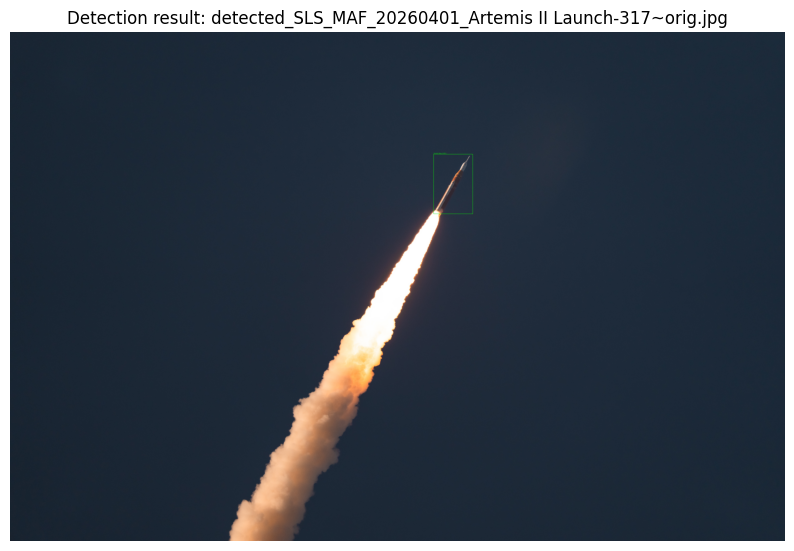

In [ ]:
from google.colab import files
from IPython.display import display
import cv2
import matplotlib.pyplot as plt

# Reload the detect module to ensure the latest changes are applied
import importlib
import detect
importlib.reload(detect)

# Now import process_image from the reloaded module
from detect import process_image

# 1. Open the browser's file picker
print("📤 Choose an image file to upload...")
uploaded = files.upload()

# 2. Run detection on each uploaded image and show the result inline
for filename in uploaded.keys():
    output_path = process_image(filename)
    if output_path is None:
        continue

    annotated = cv2.imread(output_path)
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 14))
    plt.imshow(annotated_rgb)
    plt.axis('off')
    plt.title(f"Detection result: {output_path}")
    plt.show()

## Autonomous Optical Rocket Tracking System: A Q&A Guide

This guide provides answers to common questions about the notebook's functionality and the underlying technologies.

### General System Overview

**Q1: What is the main purpose of this Colab notebook?**
**A1:** This notebook implements an Autonomous Optical Rocket Tracking System. Its primary goal is to detect rockets and their engine flames in images and videos, track them, and simulate a gimbal's pan, tilt, and zoom movements to keep the rocket centered in the camera's view.

**Q2: What files are essential to run this notebook?**
**A2:** You need to upload `rocket_yolo.pt` (your custom-trained YOLOv8 model weights) and `onboard.webm` (a sample rocket tracking video) to the Colab environment.

### Detection Module (`detect.py`)

**Q3: How does the system detect rockets and flames?**
**A3:** The `HybridDetector` class combines several techniques:
*   **YOLOv8:** A deep learning object detection model (`rocket_yolo.pt`) is used to find rocket bodies and engine flames.
*   **SAHI (Slicing Aided Hyper Inference):** For small or distant targets, SAHI is optionally used to slice the image into smaller parts, run YOLO on each slice, and then merge the results, improving detection of less prominent objects.
*   **Plume Detection:** OpenCV-based image processing (HSV and grayscale thresholding, contour detection) is used to identify hot, fire-colored exhaust plumes, which helps in cases where YOLO might miss the flame.

**Q4: How does `HybridDetector` prevent flame bounding boxes from overlapping the rocket body?**
**A4:** The `_merge_detections` function in `hybrid_detector.py` contains logic to clip engine flame bounding boxes. If a flame box extends above the bottom edge of a detected rocket body, its top edge is adjusted to `rocket_body_bottom_y`. Flame boxes that become too small (less than 5 pixels in height) after clipping are discarded.

**Q5: Why was the `importlib.reload(detect)` line added to the detection cell?**
**A5:** This line was added to forcefully reload the `detect.py` module. This is necessary in interactive environments like Colab because Python typically loads modules only once. If you modify a `.py` file and then try to import it again, Python uses the old, cached version unless explicitly told to reload it. This ensures that any changes made to `detect.py` are immediately reflected when the detection cell is run.

**Q6: What does the `process_image` function do?**
**A6:** It takes an image path, runs the hybrid detection logic, annotates the image with bounding boxes (green for rocket body, red for engine flames), and saves the annotated image. It also displays the image inline in the notebook.

**Q7: Why did a detection previously show as 'Unknown Target'?**
**A7:** This occurred because the `detect.py` script was not correctly classifying detections from `hybrid_yolo_1` (which corresponds to rocket body detections from the hybrid process) and was falling back to the default 'Unknown Target' label. This has been corrected to label it as 'Rocket Body'.

### Tracking Module (`tracker.py`)

**Q8: How does the system track the rocket in video?**
**A8:** The `RocketTracker` class employs a multi-faceted approach:
*   **Kalman Filter:** Predicts the rocket's future position, velocity, width, and height based on its past trajectory, helping to smooth movements and handle brief occlusions.
*   **Optical Flow (Lucas-Kanade):** If the primary detector loses the target, optical flow is used to track features on the rocket body between frames, providing short-term tracking during occlusions.
*   **State Machine:** Manages the tracker's state (LOST, LOCKED, OCCLUDED_FLOW, OCCLUDED_KALMAN) to adapt tracking strategies based on detection confidence and history.
*   **Shot-cut Detection:** Uses HSV histogram correlation to detect abrupt camera changes (e.g., between different camera feeds) and resets the tracker when a cut is detected.

**Q9: What is `max_occlusion_frames` in the `RocketTracker`?**
**A9:** It defines how many frames the tracker will attempt to maintain its state (using Kalman filter predictions or optical flow) after losing a direct detection. If the target is not re-acquired within this many frames, the tracker reverts to a 'LOST' state and tries to re-acquire the rocket.

### Validation Module (`domain_validator.py`)

**Q10: What is the role of `DomainValidator`?**
**A10:** This class applies domain-specific rules to filter out false positive detections. It checks for:
*   **Spatial Validation:** Filters out detections in unlikely locations based on frame index (e.g., stationary objects during liftoff).
*   **Aspect Ratio Validation:** Ensures detected objects have plausible rocket-like aspect ratios, adjusting for rocket tilt over time.
*   **Plume Position Validation:** Verifies that the plume is in a physically correct position relative to the rocket body (i.e., at the bottom).
*   **Kinematic Validation:** Checks for sudden, implausible changes in position or size between frames, indicating a likely false detection.

### Gimbal Control Module (`control_system.py`)

**Q11: How does the `GimbalSimulator` work?**
**A11:** This class simulates a camera gimbal's movement. It receives target coordinates from the `RocketTracker` and calculates the necessary pan (azimuth), tilt (elevation), and zoom adjustments to keep the rocket centered within a specified viewport. It applies smoothing to these movements for a more realistic and stable tracking effect.

**Q12: What is the `target_height_viewport` used for?**
**A12:** This parameter in `GimbalSimulator` determines the desired height of the rocket in the camera's viewport (in pixels) for the zoom controller. The gimbal adjusts its zoom level to try and maintain the rocket at this target height, ensuring it's always clearly visible without being too small or too large.

### Dependencies and Setup

**Q13: What external libraries are required for this system?**
**A13:** The main external libraries are `ultralytics` (for YOLOv8), `sahi` (for sliced inference), `opencv-python-headless` (for image processing), `pandas`, and `numpy`.

**Q14: What happens if `rocket_yolo.pt` is not found?**
**A14:** The `HybridDetector` is designed with a fallback mechanism. If `rocket_yolo.pt` is not present, it will default to using the pre-trained `yolov8n.pt` model, which is a general object detection model. This allows the system to still run, though with potentially less accurate rocket-specific detections.

### 🎥 Step: Run Video Tracking
Execute the tracking system on the uploaded video `onboard.webm`. This will process the video, control a virtual gimbal with pan/tilt/zoom dynamically, and output the tracking video.

In [ ]:
!python detect.py onboard.webm

❌ Error: File 'onboard.webm' not found!


### 📺 Step: Re-encode and Play Output Video
Convert the output video using `ffmpeg` to standard H.264 encoding so that the browser can display it directly inside Google Colab.

In [ ]:
# Re-encode video using ffmpeg for standard browser playback
!ffmpeg -y -i tracked_onboard.mp4 -vcodec libx264 -f mp4 playable_tracked_onboard.mp4

# Display the video player
from IPython.display import HTML
from base64 import b64encode
import os

if os.path.exists('playable_tracked_onboard.mp4'):
    mp4 = open('playable_tracked_onboard.mp4','rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    display(HTML(f"""
    <video width="640" height="360" controls>
          <source src="{data_url}" type="video/mp4">
    </video>
    """))
else:
    print("Error: Output video file not found!")

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab